Loading the appropriate dataset (MPG) from Python Seaborn package.

In [56]:
#Import all necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from pandas.plotting import scatter_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Load the dataset from the seaborn package (Saved in DataFrame format)
df = sb.load_dataset('mpg')

#Inspect the first lines of the dataset
print("======================================================================")
print(df.head())
print("======================================================================")
print(df.info())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2 

Discover of correlation between attributes

array([[<Axes: xlabel='mpg', ylabel='mpg'>,
        <Axes: xlabel='cylinders', ylabel='mpg'>,
        <Axes: xlabel='displacement', ylabel='mpg'>,
        <Axes: xlabel='horsepower', ylabel='mpg'>,
        <Axes: xlabel='weight', ylabel='mpg'>,
        <Axes: xlabel='acceleration', ylabel='mpg'>,
        <Axes: xlabel='model_year', ylabel='mpg'>],
       [<Axes: xlabel='mpg', ylabel='cylinders'>,
        <Axes: xlabel='cylinders', ylabel='cylinders'>,
        <Axes: xlabel='displacement', ylabel='cylinders'>,
        <Axes: xlabel='horsepower', ylabel='cylinders'>,
        <Axes: xlabel='weight', ylabel='cylinders'>,
        <Axes: xlabel='acceleration', ylabel='cylinders'>,
        <Axes: xlabel='model_year', ylabel='cylinders'>],
       [<Axes: xlabel='mpg', ylabel='displacement'>,
        <Axes: xlabel='cylinders', ylabel='displacement'>,
        <Axes: xlabel='displacement', ylabel='displacement'>,
        <Axes: xlabel='horsepower', ylabel='displacement'>,
        <Axes: xlabel='w

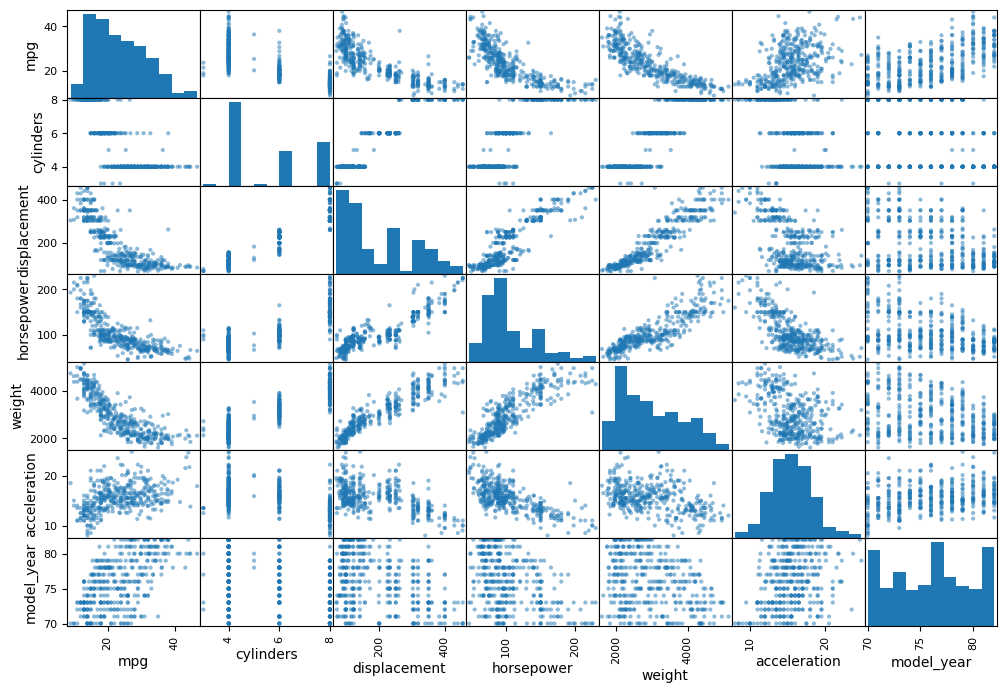

In [51]:
print("======================================================================")
# Visualise potential correlation
attributes=["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
scatter_matrix(df_clear[attributes], figsize=(12,8))

Remarks for question 2: Target value is the "mpg" attribute and the predictors are the rest of the attributes. Based on the scatter plots, there is a significant correlation between "mpg" and "displacement", "horsepower", "weight" and "acceleration".

Descriptive Statistics

In [52]:
print("======================================================================")
print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  392.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.469388  2970.424623   
std      7.815984    1.701004    104.269838   38.491160   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   75.000000  2223.750000   
50%     23.000000    4.000000    148.500000   93.500000  2803.500000   
75%     29.000000    8.000000    262.000000  126.000000  3608.000000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    398.000000  398.000000  
mean      15.568090   76.010050  
std        2.757689    3.697627  
min        8.000000   70.000000  
25%       13.825000   73.000000  
50%       15.500000   76.000000  
75%       17.175000   79.000000  
max       24.800000   82.000000  


Remarks for question 3: (categorical attributes are automaticaly removed by the function).
Most insteresting insights:
- "horsepower" attibute has a lack of 6 values, ie 6 cars has no value in the specific attribute.
- 9.00 minimum value in "mpg" attribute represents very poor fuel efficiency in some cars.
- 5.45 mean in "cylinders" attribute, with most cars in the dataset having 4 to 6 cylinders.
- The large range (68 to 455) of "displacement" attribute suggests a wide variety of vehicles with different engine sizes (small vehicles, lorries, trucks etc).
- 75 and 126 horsepower in 25% and 75% quartiles means that most cars have engine power in the range of 75–126 hp which are usually medium/family cars.
- The IQR (2223.75 to 3608 pounds) in "weight" attribute shows that the majority of cars are in the mid-weight range (between these values).
- SD of 846.84 pounds in "weight" attribute suggesting that there are some very heavy vehicles compared to lighter ones.
- The interquartile range (13.83 to 17.18) in "acceleration" attribute shows that most vehicles accelerate between these values, which is relatively slow compared to modern standards or it is skewed because of potential large amount of large/heavy vehicles.
- Mean value of 76.01 in "model_year" attribute, indicates that the dataset contains cars manufactured mainly in the 70s.

Cleaning the dataset / Remove Categorical values / Create Histograms

Correlation with 'mpg':
mpg             1.000000
model_year      0.580541
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64


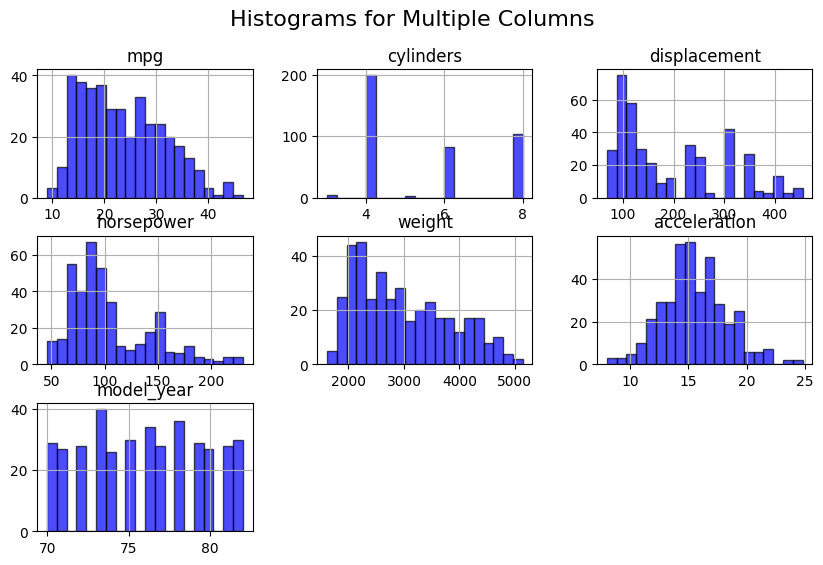

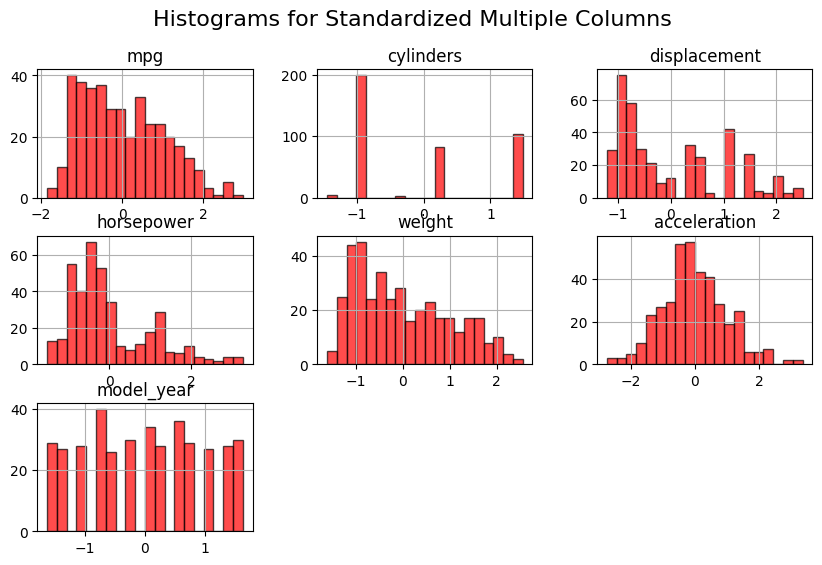

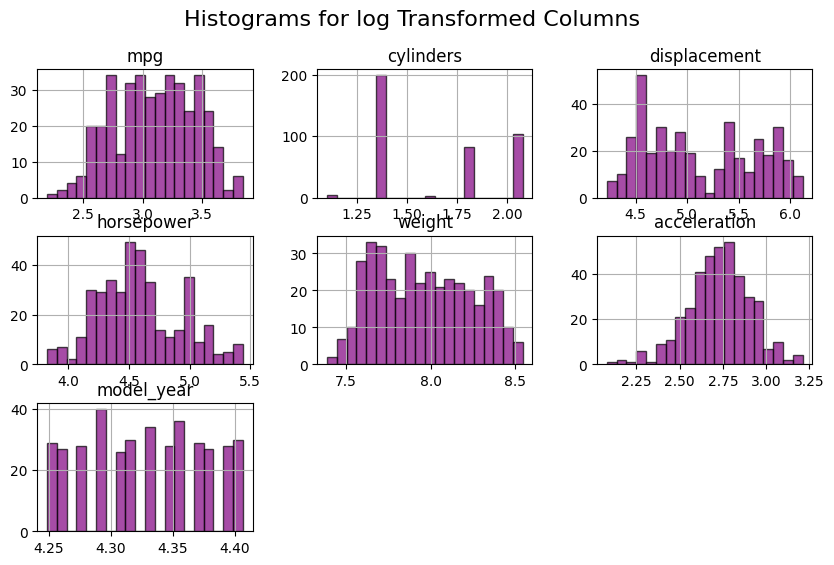

In [71]:
# Remove dataset's records with missing values (NaN)
df_cleaned = df.dropna()

# Creation of a new dataset with only numerical attributes
df_clear = df_cleaned.select_dtypes(include=['number'])

print("======================================================================")
# Creation of correlation matrix to define influence of mpg
corr_matrix = df_clear.corr()
print("Correlation with 'mpg':")
print(corr_matrix["mpg"].sort_values(ascending=False))

print("======================================================================")
# Plot histograms for multiple columns
columns_to_plot = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

df_clear[columns_to_plot].hist(bins=20, figsize=(10, 6), edgecolor='black', color='blue', alpha=0.7)

# Add titles and labels
plt.suptitle('Histograms for Multiple Columns', fontsize=16)
plt.show()

print("======================================================================")
# Make a copy of the dataset
df_copy = df_clear.copy()
df_copy_2 = df_clear.copy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply the scaler to standardize the dataset
standardized_data = scaler.fit_transform(df_copy)

# Convert the standardized data back to a DataFrame
df_copy_standardized = pd.DataFrame(standardized_data, columns=df_copy.columns)
df_copy_standardized[columns_to_plot].hist(bins=20, figsize=(10, 6), edgecolor='black', color='red', alpha=0.7)

# Add titles and labels
plt.suptitle('Histograms for Standardized Multiple Columns', fontsize=16)
plt.show()

print("======================================================================")
# Apply log tranformation to the initial dataset
df_copy_2 = np.log(df_copy_2[df_copy_2 > 0])

# Convert the transformed data to a DataFrame
df_copy_2[columns_to_plot].hist(bins=20, figsize=(10, 6), edgecolor='black', color='purple', alpha=0.7)

# Add titles and labels
plt.suptitle('Histograms for log Transformed Columns', fontsize=16)
plt.show()